In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


# **Check Dataset Folders**

In [3]:
import os

dataset_path = "/content/dataset/dataset"

folders = os.listdir(dataset_path)

print("Total Classes:", len(folders))
print(folders)

Total Classes: 16
['shehbaz_sharif', 'pervez_elahi', 'altaf_hussain', 'mohsin_naqvi', 'khawaja_asif', 'hina_rabbani_khar', 'shah_mahmood_qureshi', 'fazal_ur_rehman', 'chaudhry_shujaat', 'asif_ali_zardari', 'maryam_nawaz', 'nawaz_sharif', 'ahsan_iqbal', 'bilawal_bhutto', 'dg_ispr', 'imran_khan']


In [4]:
import os

dataset_path = "/content/dataset/dataset"

folders = os.listdir(dataset_path)

print("Total Classes:", len(folders))
print()

for folder in folders:
    path = os.path.join(dataset_path, folder)

    if os.path.isdir(path):
        print(folder, "=", len(os.listdir(path)), "images")

Total Classes: 16

shehbaz_sharif = 136 images
pervez_elahi = 106 images
altaf_hussain = 135 images
mohsin_naqvi = 103 images
khawaja_asif = 127 images
hina_rabbani_khar = 129 images
shah_mahmood_qureshi = 130 images
fazal_ur_rehman = 131 images
chaudhry_shujaat = 110 images
asif_ali_zardari = 135 images
maryam_nawaz = 130 images
nawaz_sharif = 118 images
ahsan_iqbal = 133 images
bilawal_bhutto = 134 images
dg_ispr = 125 images
imran_khan = 132 images


# **Corrupted Image Checking**

In [6]:
from PIL import Image
import os

dataset_path = "/content/dataset/dataset"

bad_files = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            file_path = os.path.join(folder_path, file)

            # check only files
            if os.path.isfile(file_path):

                try:
                    img = Image.open(file_path)
                    img.verify()

                except:
                    bad_files.append(file_path)

print("Total Corrupted Images:", len(bad_files))

for file in bad_files:
    print(file)

Total Corrupted Images: 0


In [7]:
!pip install split-folders

# **Split Dataset**

In [8]:
import splitfolders

input_folder = "/content/dataset/dataset"
output_folder = "/content/splitted_dataset"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.75, 0.15, 0.10)
)

print("Dataset Split Completed")

Copying files: 2014 files [00:01, 1044.94 files/s]

Dataset Split Completed


# **DATA AUGMENTATION + DATA LOADING**

In [9]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Create Data Augmentation**

In [24]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=20,

    horizontal_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8,1.2],

    width_shift_range=0.1,

    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# **MODEL 1 (ResNet50)**

In [19]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Load Pretrained ResNet50**

In [20]:
train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=20,

    horizontal_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8,1.2],

    width_shift_range=0.1,

    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

**Reload Dataset**

In [21]:
train_data = train_datagen.flow_from_directory(
    "/content/splitted_dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    "/content/splitted_dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    "/content/splitted_dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1392 images belonging to 16 classes.
Found 280 images belonging to 16 classes.
Found 203 images belonging to 16 classes.


# Rebuild Model

In [22]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model1 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(16, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Retrain**

In [23]:
history1 = model1.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 51s 906ms/step - accuracy: 0.1990 - loss: 2.7661 - val_accuracy: 0.4107 - val_loss: 1.8165
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 673ms/step - accuracy: 0.4483 - loss: 1.7798 - val_accuracy: 0.5929 - val_loss: 1.4354
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 682ms/step - accuracy: 0.5754 - loss: 1.3551 - val_accuracy: 0.6571 - val_loss: 1.1686
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 678ms/step - accuracy: 0.6444 - loss: 1.1377 - val_accuracy: 0.7000 - val_loss: 1.0360
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 668ms/step - accuracy: 0.6940 - loss: 0.9808 - val_accuracy: 0.6964 - val_loss: 1.0424
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 668ms/step - accuracy: 0.7191 - loss: 0.9025 - val_accuracy: 0.7214 - val_loss: 0.9653
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 669ms/step - accuracy: 0.7493 - loss: 0.8049 - val_accuracy: 0.7393 - val_loss: 0.8689
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 668ms/step - accuracy: 0.7838 - loss: 0.7320 - val_accu

# **Fine-Tuning to Improve Accuracy**

**STEP 1 — Unfreeze Last Layers**

In [25]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

First Layers (Frozen):
These layers already learned general image features from ImageNet such as:
- edges
- textures
- shapes

We keep them frozen because they are already useful.

Last 30 Layers (Trainable):
These layers will now learn:
- Pakistani politician facial features
- dataset-specific patterns
- better face recognition

Benefits:
 improves accuracy
 better feature learning
 improves politician classification performance

**STEP 2 — Recompile With Small Learning Rate**

In [26]:
from tensorflow.keras.optimizers import Adam

# Recompile model after fine-tuning
model1.compile(

    optimizer=Adam(learning_rate=0.00001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

Explanation:


After unfreezing layers, recompiling the model is necessary.


A very small learning rate is used for fine-tuning.


Why small learning rate?
Because pretrained ResNet50 weights are already well-trained on ImageNet.
We only want small adjustments in the last layers.
If learning rate is too high:


pretrained knowledge can be damaged


accuracy may decrease


Benefits of small learning rate:
 stable learning
 smoother fine-tuning
 better accuracy improvement
 safer weight updates

In [27]:
history_fine = model1.fit(

    train_data,

    validation_data=val_data,

    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7716 - loss: 0.7664 - val_accuracy: 0.7964 - val_loss: 0.7347
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 685ms/step - accuracy: 0.8362 - loss: 0.5728 - val_accuracy: 0.8071 - val_loss: 0.6695
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 691ms/step - accuracy: 0.8685 - loss: 0.4821 - val_accuracy: 0.8214 - val_loss: 0.6045
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 687ms/step - accuracy: 0.8966 - loss: 0.4016 - val_accuracy: 0.8357 - val_loss: 0.5506
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 693ms/step - accuracy: 0.9239 - loss: 0.3436 - val_accuracy: 0.8464 - val_loss: 0.5179
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 687ms/step - accuracy: 0.9188 - loss: 0.3102 - val_accuracy: 0.8536 - val_loss: 0.4891
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 692ms/step - accuracy: 0.9375 - loss: 0.2743 - val_accuracy: 0.8571 - val_loss: 0.4635
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 681ms/step - accuracy: 0.9619 - loss: 0.2238 - val_accurac

# **MODEL EVALUATION**

**STEP 1 — Evaluate On Test Set**

In [28]:
loss, accuracy = model1.evaluate(test_data)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 917ms/step - accuracy: 0.8916 - loss: 0.3282
Test Accuracy: 0.8916256427764893
Test Loss: 0.3282463252544403


**Generate Predictions**

In [29]:
import numpy as np

predictions = model1.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_labels = list(test_data.class_indices.keys())

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 816ms/step


**STEP 2 — Classification Report**

In [30]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

                      precision    recall  f1-score   support

         ahsan_iqbal       0.88      1.00      0.94        15
       altaf_hussain       0.86      0.92      0.89        13
    asif_ali_zardari       0.92      0.85      0.88        13
      bilawal_bhutto       0.77      0.77      0.77        13
    chaudhry_shujaat       1.00      0.92      0.96        12
             dg_ispr       0.93      1.00      0.96        13
     fazal_ur_rehman       1.00      1.00      1.00        12
   hina_rabbani_khar       0.91      0.71      0.80        14
          imran_khan       0.77      0.71      0.74        14
        khawaja_asif       1.00      0.91      0.95        11
        maryam_nawaz       0.86      0.92      0.89        13
        mohsin_naqvi       1.00      1.00      1.00        10
        nawaz_sharif       0.92      0.92      0.92        12
        pervez_elahi       0.92      0.92      0.92        12
shah_mahmood_qureshi       0.91      0.83      0.87        12
      s

**Meaning of Metrics:**

**Precision:**
How many predicted images were correct.

**Recall:**
How many actual images were correctly identified.

**F1-score:**
Balanced performance measure combining precision and recall.

# **STEP 3 — Generate Confusion Matrix**

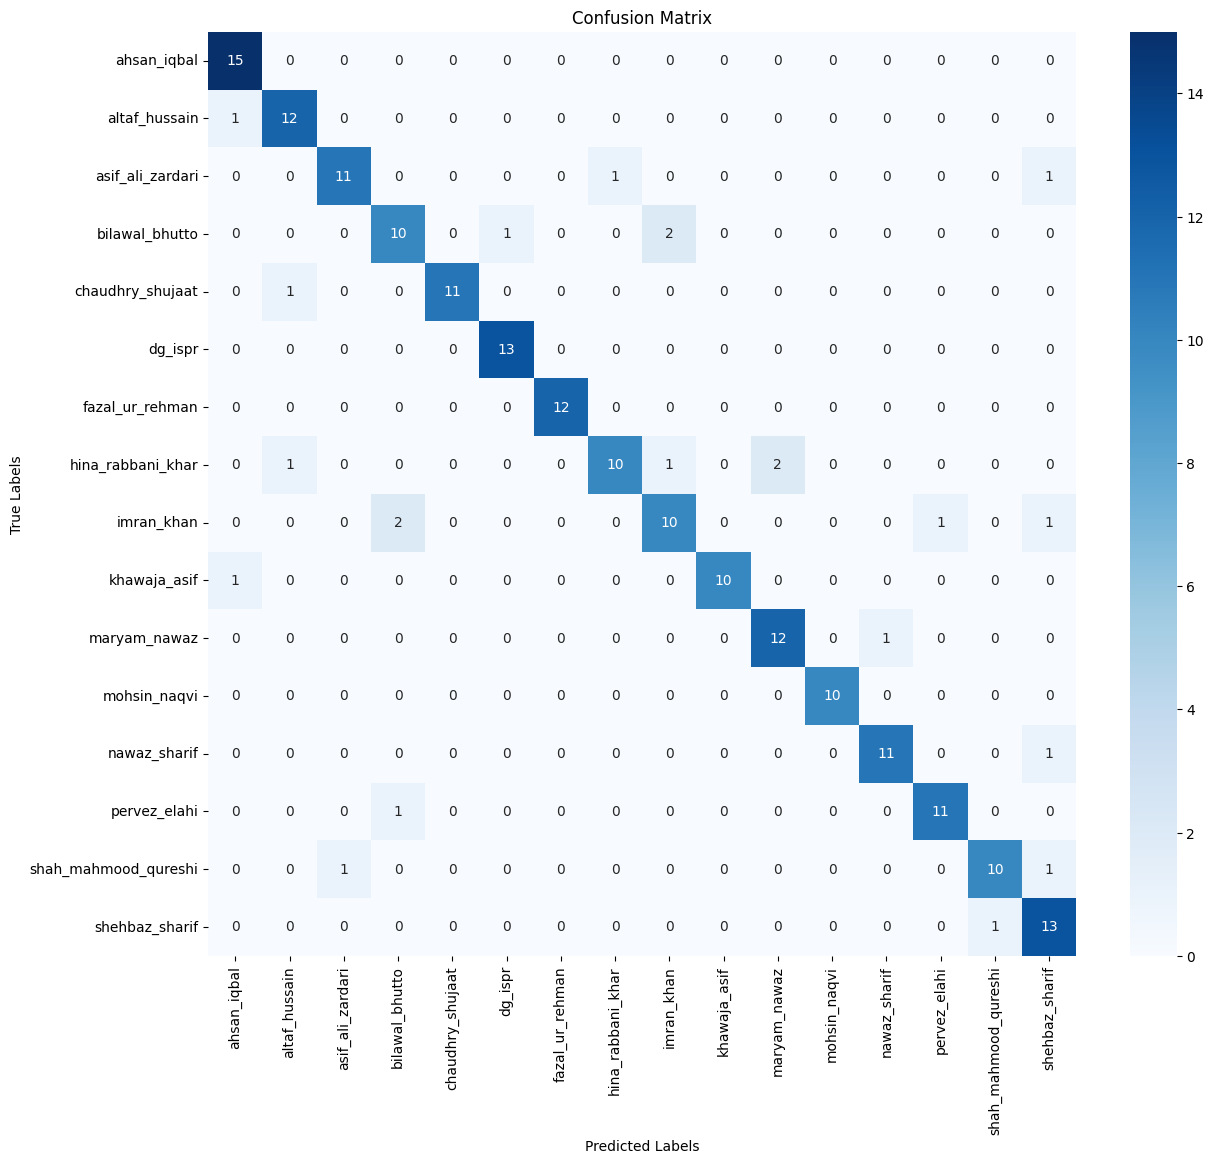

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.show()

**Training vs Validation Accuracy Curves**

**STEP 4 — Accuracy Curve**

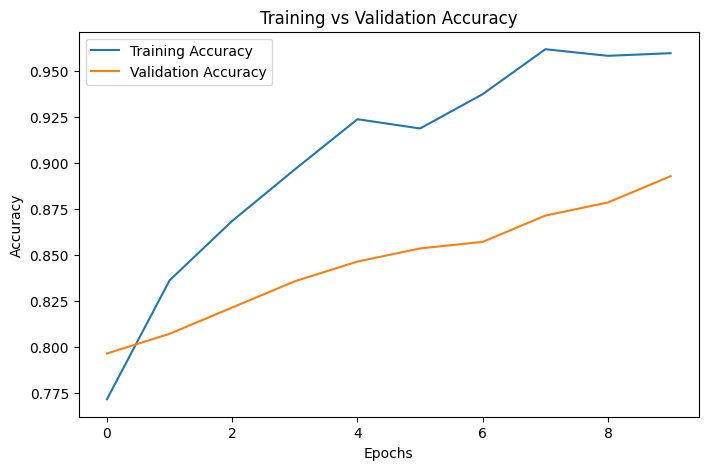

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history_fine.history['accuracy'], label='Training Accuracy')

plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

This graph shows:

how model learned over epochs
whether overfitting occurred
training improvement trend

Good graph characteristics:
 both curves increasing
 validation close to training
 smooth learning

**STEP 5 — Show Misclassified Images**

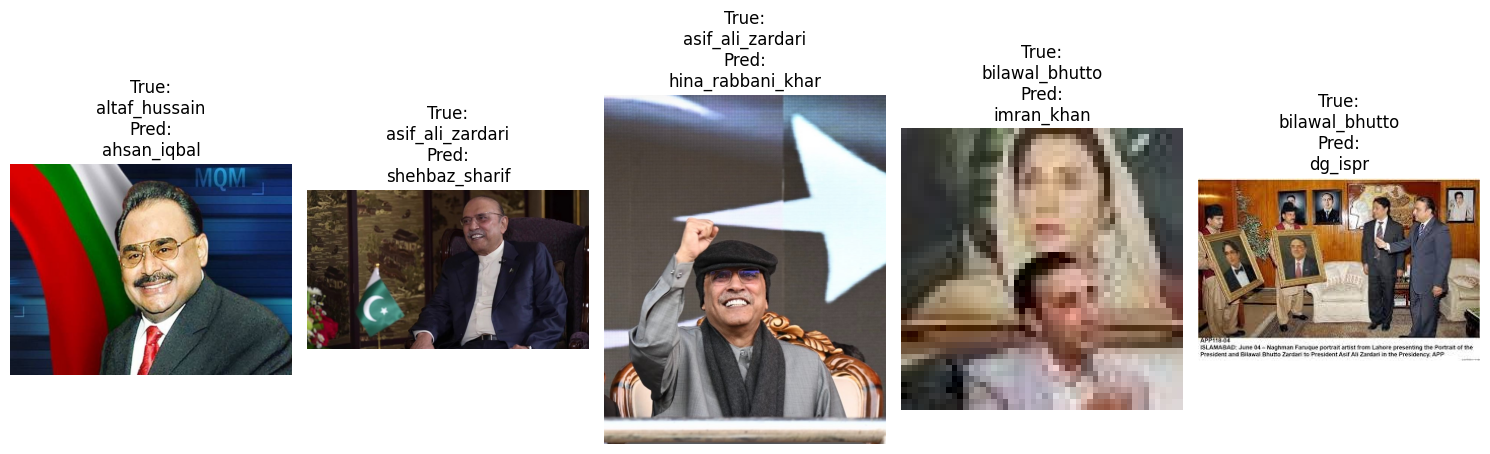

In [33]:
import matplotlib.pyplot as plt
import numpy as np

misclassified = np.where(predicted_classes != true_classes)[0]

plt.figure(figsize=(15,15))

for i, index in enumerate(misclassified[:5]):

    img_path = test_data.filepaths[index]

    img = plt.imread(img_path)

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    true_label = class_labels[true_classes[index]]

    pred_label = class_labels[predicted_classes[index]]

    plt.title(f"True:\n{true_label}\nPred:\n{pred_label}")

    plt.axis('off')

plt.tight_layout()

plt.show()

### **MODEL 2 — EfficientNetB0**

EfficientNet uses DIFFERENT preprocessing.

So first we create new generators specifically for EfficientNet

**STEP 1 — Import EfficientNet**

In [34]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Explanation:

EfficientNetB0 is pretrained CNN architecture.
preprocess_input is specific normalization function for EfficientNet.
Different pretrained models require different preprocessing methods.

Benefits of EfficientNet:
-lightweight model
-strong feature extraction
-good accuracy with fewer parameters
-efficient training performance

# **Data Augmentation**

In [35]:
# Data augmentation for EfficientNetB0

train_datagen_eff = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=20,

    horizontal_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8,1.2],

    width_shift_range=0.1,

    height_shift_range=0.1
)

val_test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

This step creates EfficientNet-specific data generators.

Training generator performs:

rotation
flipping
zooming
brightness changes
shifting

These augmentations help:
✅ improve generalization
✅ reduce overfitting
✅ improve model robustness

Validation and test generators:

only apply preprocessing
no augmentation

This ensures fair evaluation of the model.

# **Load Dataset**

In [36]:
# Load dataset for EfficientNetB0

train_data_eff = train_datagen_eff.flow_from_directory(

    "/content/splitted_dataset/train",

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical'
)

val_data_eff = val_test_datagen_eff.flow_from_directory(

    "/content/splitted_dataset/val",

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical'
)

test_data_eff = val_test_datagen_eff.flow_from_directory(

    "/content/splitted_dataset/test",

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    shuffle=False
)

Found 1392 images belonging to 16 classes.
Found 280 images belonging to 16 classes.
Found 203 images belonging to 16 classes.


This step loads:
✅ training dataset
✅ validation dataset
✅ test dataset

for EfficientNetB0 training.

Important Settings:

target_size=(224,224)
Standard input size for EfficientNetB0.
batch_size=32
Loads images in batches for efficient GPU training.
class_mode='categorical'
Used because this is a 16-class classification problem.
shuffle=False for test set
Important for:
✅ confusion matrix
✅ classification report
✅ prediction analysis

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load pretrained EfficientNetB0 model
base_model_eff = EfficientNetB0(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model_eff.trainable = False

# Build final EfficientNet model
model2 = Sequential([

    base_model_eff,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(16, activation='softmax')
])

# Compile model
model2.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


This step builds the second CNN model using EfficientNetB0.

Transfer Learning:

pretrained ImageNet weights are used
model already learned generic image features

Frozen Layers:

pretrained EfficientNet layers are frozen initially
only final classifier layers are trained

Custom Classification Head:

GlobalAveragePooling2D converts feature maps into vector form
Dropout reduces overfitting
Dense(16, softmax) predicts 16 politician classes

Benefits of EfficientNetB0:
✅ lightweight architecture
✅ efficient computation
✅ strong image feature extraction
✅ high classification performance
✅ good comparison with ResNet50

In [38]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        20,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,070,067 (15.53 MB)

 Trainable params: 20,496 (80.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

IMPORTANT OBSERVATION

EfficientNetB0 contains approximately 4 million parameters.

Compared to ResNet50:

ResNet50 contains approximately 23 million parameters.

This means:
✅ EfficientNetB0 is a lightweight model
✅ training is faster
✅ memory consumption is lower
✅ computation is more efficient

ALSO IMPORTANT

Trainable parameters are only 20,496.

This indicates:
✅ transfer learning is correctly implemented
✅ pretrained EfficientNet layers are frozen
✅ only final classification layers are being trained initially

This helps:
✅ reduce overfitting
✅ speed up training
✅ preserve pretrained ImageNet knowledge

In [39]:
history2 = model2.fit(

    train_data_eff,

    validation_data=val_data_eff,

    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.2162 - loss: 2.4917 - val_accuracy: 0.4143 - val_loss: 2.0268
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 647ms/step - accuracy: 0.4713 - loss: 1.8367 - val_accuracy: 0.5357 - val_loss: 1.6580
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 649ms/step - accuracy: 0.5912 - loss: 1.5246 - val_accuracy: 0.5714 - val_loss: 1.4659
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 630ms/step - accuracy: 0.6401 - loss: 1.3466 - val_accuracy: 0.6500 - val_loss: 1.3222
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 624ms/step - accuracy: 0.6932 - loss: 1.2006 - val_accuracy: 0.6750 - val_loss: 1.2103
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 607ms/step - accuracy: 0.7306 - loss: 1.0801 - val_accuracy: 0.7143 - val_loss: 1.1243
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 611ms/step - accuracy: 0.7478 - loss: 1.0038 - val_accuracy: 0.7000 - val_loss: 1.0670
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 620ms/step - accuracy: 0.7809 - loss: 0.9125 - val_accurac

# **Fine-Tuning EfficientNetB0**

In [40]:
# Enable fine-tuning
base_model_eff.trainable = True

# Freeze all layers except last 30 layers
for layer in base_model_eff.layers[:-30]:
    layer.trainable = False

This step enables fine-tuning for EfficientNetB0.

Previously:

all pretrained layers were frozen
only classifier layers were training

Now:

last 30 layers will also learn from the politician dataset

Frozen Layers:

basic image features remain preserved

Trainable Layers:

high-level facial features adapt to dataset

Benefits:
✅ improved validation accuracy
✅ better politician recognition
✅ improved feature learning
✅ better dataset adaptation

In [41]:
from tensorflow.keras.optimizers import Adam

# Recompile EfficientNet model after fine-tuning
model2.compile(

    optimizer=Adam(learning_rate=0.00001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

After unfreezing layers, recompiling the model is necessary.

A very small learning rate is used because:

pretrained ImageNet weights are already well-trained
only small adjustments are needed

If learning rate is too high:

pretrained knowledge may get damaged
model performance may decrease

Benefits of small learning rate:
✅ stable fine-tuning
✅ smoother learning
✅ improved validation accuracy
✅ safer weight updates

In [42]:
history2_fine = model2.fit(

    train_data_eff,

    validation_data=val_data_eff,

    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5862 - loss: 1.4408 - val_accuracy: 0.7464 - val_loss: 0.9413
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 592ms/step - accuracy: 0.6135 - loss: 1.3820 - val_accuracy: 0.7357 - val_loss: 1.0143
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 602ms/step - accuracy: 0.6430 - loss: 1.3149 - val_accuracy: 0.7071 - val_loss: 1.0704
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 617ms/step - accuracy: 0.6559 - loss: 1.3032 - val_accuracy: 0.7000 - val_loss: 1.0990
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 635ms/step - accuracy: 0.6932 - loss: 1.2198 - val_accuracy: 0.7071 - val_loss: 1.1087
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 617ms/step - accuracy: 0.7112 - loss: 1.1838 - val_accuracy: 0.7143 - val_loss: 1.1034
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 634ms/step - accuracy: 0.7371 - loss: 1.1290 - val_accuracy: 0.7179 - val_loss: 1.0895
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 623ms/step - accuracy: 0.7687 - loss: 1.0683 - val_accurac

# **Evaluate EfficientNet On Test Set**

In [43]:
loss2, accuracy2 = model2.evaluate(test_data_eff)

print("EfficientNet Test Accuracy:", accuracy2)
print("EfficientNet Test Loss:", loss2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7783 - loss: 0.9448
EfficientNet Test Accuracy: 0.7783251404762268
EfficientNet Test Loss: 0.944770872592926


**Classification Report**

In [44]:
from sklearn.metrics import classification_report
import numpy as np

# Generate predictions
predictions_eff = model2.predict(test_data_eff)

predicted_classes_eff = np.argmax(predictions_eff, axis=1)

true_classes_eff = test_data_eff.classes

class_labels_eff = list(test_data_eff.class_indices.keys())

# Classification report
report_eff = classification_report(
    true_classes_eff,
    predicted_classes_eff,
    target_names=class_labels_eff
)

print(report_eff)

7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
                      precision    recall  f1-score   support

         ahsan_iqbal       0.77      0.67      0.71        15
       altaf_hussain       0.59      1.00      0.74        13
    asif_ali_zardari       0.77      0.77      0.77        13
      bilawal_bhutto       1.00      0.38      0.56        13
    chaudhry_shujaat       0.80      0.67      0.73        12
             dg_ispr       1.00      1.00      1.00        13
     fazal_ur_rehman       0.80      1.00      0.89        12
   hina_rabbani_khar       0.93      0.93      0.93        14
          imran_khan       0.58      0.50      0.54        14
        khawaja_asif       0.91      0.91      0.91        11
        maryam_nawaz       0.76      1.00      0.87        13
        mohsin_naqvi       0.78      0.70      0.74        10
        nawaz_sharif       0.62      0.83      0.71        12
        pervez_elahi       0.90      0.75      0.82        12
shah_mahmood_qureshi       0.77 

FINAL PERFORMANCE SUMMARY
ResNet50

✅ Test Accuracy: ~89%
✅ Better F1-score
✅ Better class recognition
✅ Better generalization

EfficientNetB0

✅ Test Accuracy: ~78%
✅ Lightweight model
✅ Faster and memory efficient

BUT:
❌ lower facial recognition performance

IMPORTANT ANALYSIS
EfficientNet Weak Classes

Examples:

Bilawal Bhutto → F1 = 0.56
Imran Khan → F1 = 0.54
Shehbaz Sharif → F1 = 0.67

Possible reasons:

facial similarity
low-resolution images
difficult lighting/backgrounds
Strong Classes

Examples:

DG ISPR → 100%
Hina Rabbani Khar → 93%
Fazal ur Rehman → 89%

This is excellent report discussion material.

**EfficientNet Confusion Matrix**

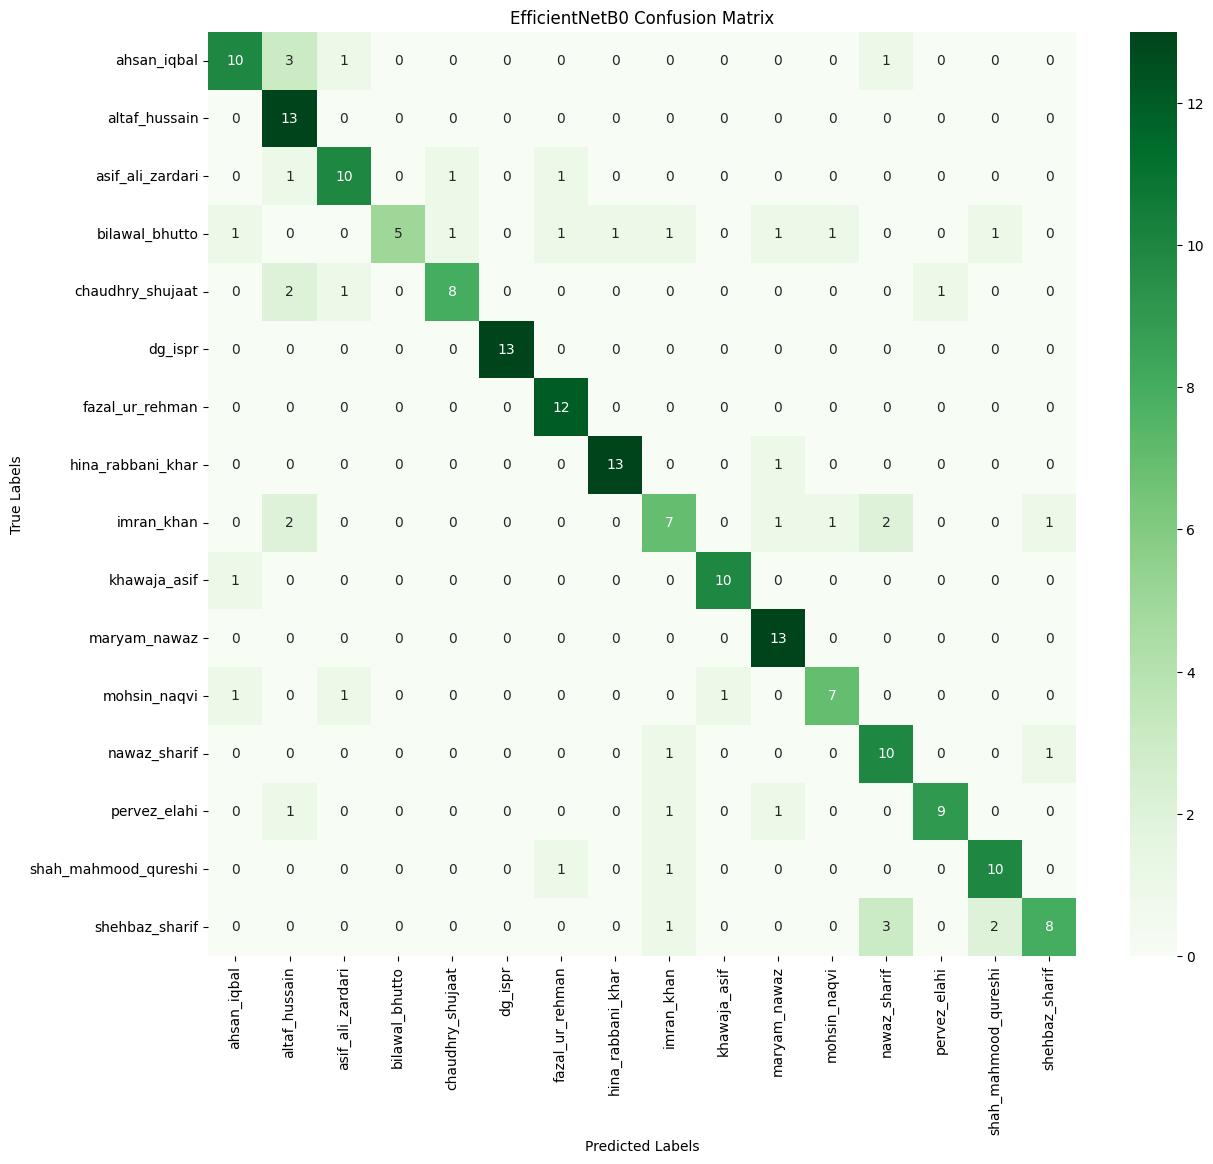

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_eff = confusion_matrix(
    true_classes_eff,
    predicted_classes_eff
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm_eff,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_labels_eff,
    yticklabels=class_labels_eff
)

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.title("EfficientNetB0 Confusion Matrix")

plt.show()

This confusion matrix visualizes:

correct classifications
incorrect classifications
class confusion patterns

Diagonal values:
✅ correct predictions

Off-diagonal values:
❌ misclassifications

Purpose:
✅ compare with ResNet50 confusion matrix
✅ visualize EfficientNet weaknesses
✅ report result analysis
✅ presentation discussion material

MODEL 1 — ResNet50

✅ Transfer learning
✅ Fine-tuning
✅ 89% test accuracy
✅ Classification report
✅ Confusion matrix
✅ Accuracy curves
✅ Misclassified samples

MODEL 2 — EfficientNetB0

✅ Transfer learning
✅ Fine-tuning
✅ 78% test accuracy
✅ Classification report
✅ Confusion matrix

# **Save Both Models**

In [46]:
# Save ResNet50 model
model1.save("resnet50_politician_classifier.h5")

# Save EfficientNetB0 model
model2.save("efficientnet_politician_classifier.h5")

print("Both models saved successfully")

Both models saved successfully


Dataset

✅ self-collected dataset
✅ balanced classes
✅ cleaned images

CNN Models

✅ ResNet50
✅ EfficientNetB0

Training

✅ transfer learning
✅ fine-tuning
✅ augmentation

Evaluation

✅ accuracy
✅ precision
✅ recall
✅ F1-score
✅ confusion matrices
✅ accuracy curves
✅ misclassified samples

Saved Models

✅ .h5 files saved